# 01 - Data Preparation

**Thesis**: Multimodal Explainable AI for Breast Histopathology Classification  
**Dataset**: BreakHis 400X (Breast Cancer Histopathological Database)  
**Task**: 8-class subtype classification

---

This notebook covers:
1. **Dataset Download** - Fetching BreakHis 400X from Kaggle
2. **Exploration** - Understanding the data (class distribution, sample images)
3. **Stain Normalization** - Macenko & Reinhard methods (ablation study)
4. **Preprocessing** - Augmentation pipeline, train/val/test split
5. **DataLoader Verification** - Confirming everything works end-to-end

## 1. Environment Setup

In [1]:
import os
import sys
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from pathlib import Path
from collections import Counter
from tqdm.notebook import tqdm

import torch
import torchvision
from torchvision import transforms

# Add src/ to path so we can import our modules
sys.path.insert(0, os.path.abspath("."))
from src.config import *
from src.stain_normalization import MacenkoNormalizer, ReinhardNormalizer, get_normalizer
from src.dataset import BreakHisDataset, get_transforms, create_dataloaders, compute_class_weights

# Reproducibility
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# Plot settings
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA/ROCm available: {torch.cuda.is_available()}")
print(f"Device : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"Project root : {PROJECT_ROOT}")

PyTorch version : 2.5.1+rocm6.2
CUDA/ROCm available: True
Device : AMD Radeon RX 6800 XT
Project root : /home/abdullah/Documents/GitHub/Personal/densnet-thesis/thesis-v1-agent-abdullah


In [2]:
# Create all project directories
ensure_dirs()
print("Project directories created:")
for d in [DATA_DIR, RAW_DATA_DIR, PROCESSED_DATA_DIR, NORMALIZED_DATA_DIR, WEIGHTS_DIR, RESULTS_DIR, FIGURES_DIR]:
    print(f"  {os.path.relpath(d, PROJECT_ROOT)}/")

Project directories created:
  data/
  data/raw/
  data/processed/
  data/normalized/
  weights/
  results/
  figures/


## 2. Dataset Download

### About BreakHis

**BreakHis** (Breast Cancer Histopathological Image Database) is a benchmark dataset of microscope images from breast tissue biopsies. Key facts:

| Property | Value |
|----------|-------|
| Source | P&D Laboratory, Brazil |
| Magnification | 400X (cellular-level detail) |
| Image size | 700 x 460 pixels |
| Staining | H&E (Hematoxylin & Eosin) |
| Classes | 8 subtypes (4 benign + 4 malignant) |

**Why 400X?** At this magnification, pathologists can see nuclear details (shape, chromatin texture, mitotic figures) that distinguish cancer subtypes. Lower magnifications show overall tissue architecture but miss the fine-grained cellular features we need for 8-class classification.

**The 8 classes:**
- **Benign**: Adenosis, Fibroadenoma, Phyllodes Tumor, Tubular Adenoma
- **Malignant**: Ductal Carcinoma, Lobular Carcinoma, Mucinous Carcinoma, Papillary Carcinoma

In [3]:
# Download BreakHis 400X from Kaggle
# Prerequisites: pip install kaggle
# Place your kaggle.json in ~/.kaggle/ or set KAGGLE_USERNAME and KAGGLE_KEY env vars

import subprocess

dataset_marker = os.path.join(RAW_DATA_DIR, ".download_complete")

if os.path.exists(dataset_marker):
    print("Dataset already downloaded. Skipping.")
else:
    print(f"Downloading {KAGGLE_DATASET} to {RAW_DATA_DIR} ...")
    result = subprocess.run(
        ["kaggle", "datasets", "download", "-d", KAGGLE_DATASET, "-p", RAW_DATA_DIR, "--unzip"],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        Path(dataset_marker).touch()
        print("Download complete!")
    else:
        print(f"Download failed:\n{result.stderr}")
        print("\nIf you get an authentication error, run:")
        print("  mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json")

Dataset already downloaded. Skipping.


In [4]:
# Discover the dataset structure (Kaggle zips can nest folders unpredictably)
print("Raw data directory contents:\n")
for root, dirs, files in os.walk(RAW_DATA_DIR):
    depth = root.replace(RAW_DATA_DIR, "").count(os.sep)
    indent = "  " * depth
    print(f"{indent}{os.path.basename(root)}/")
    if depth < 3:  # only show first 3 levels
        for f in files[:5]:
            print(f"{indent}  {f}")
        if len(files) > 5:
            print(f"{indent}  ... and {len(files) - 5} more files")

Raw data directory contents:

raw/
  .download_complete
  BreaKHis 400X/
    test/
      benign/
      malignant/
    train/
      benign/
      malignant/


### Organize into a Standard Structure

The Kaggle download has images in flat `benign/` and `malignant/` folders, with the **subtype encoded in the filename**:

| Filename prefix | Class |
|---|---|
| `SOB_B_A-` | Adenosis (Benign) |
| `SOB_B_F-` | Fibroadenoma (Benign) |
| `SOB_B_PT-` | Phyllodes Tumor (Benign) |
| `SOB_B_TA-` | Tubular Adenoma (Benign) |
| `SOB_M_DC-` | Ductal Carcinoma (Malignant) |
| `SOB_M_LC-` | Lobular Carcinoma (Malignant) |
| `SOB_M_MC-` | Mucinous Carcinoma (Malignant) |
| `SOB_M_PC-` | Papillary Carcinoma (Malignant) |

We reorganize into one folder per class - the standard format for `torchvision.datasets.ImageFolder`.

In [5]:
# Organize raw images by subtype using filename prefixes
ORGANIZED_DIR = os.path.join(RAW_DATA_DIR, "organized")

# Map filename prefixes to our class names
PREFIX_TO_CLASS = {
    "SOB_B_A":  "adenosis",
    "SOB_B_F":  "fibroadenoma",
    "SOB_B_PT": "phyllodes_tumor",
    "SOB_B_TA": "tubular_adenoma",
    "SOB_M_DC": "ductal_carcinoma",
    "SOB_M_LC": "lobular_carcinoma",
    "SOB_M_MC": "mucinous_carcinoma",
    "SOB_M_PC": "papillary_carcinoma",
}

def get_class_from_filename(filename):
    """Extract class from BreakHis filename like SOB_B_A-14-22549AB-400-002.png"""
    for prefix, cls_name in PREFIX_TO_CLASS.items():
        if filename.startswith(prefix):
            return cls_name
    return None

def organize_dataset(raw_dir, organized_dir):
    """Sort all images into class subfolders based on filename prefix."""
    # Check if already done
    if os.path.exists(organized_dir):
        subdirs = [d for d in os.listdir(organized_dir) if os.path.isdir(os.path.join(organized_dir, d))]
        if len(subdirs) == 8:
            total = sum(len(os.listdir(os.path.join(organized_dir, d))) for d in subdirs)
            if total > 0:
                print(f"Dataset already organized ({total} images). Skipping.")
                return

    os.makedirs(organized_dir, exist_ok=True)
    copied = 0

    for root, dirs, files in os.walk(raw_dir):
        if "organized" in root:
            continue
        for f in files:
            if not f.lower().endswith((".png", ".jpg", ".jpeg")):
                continue
            cls_name = get_class_from_filename(f)
            if cls_name is None:
                continue
            target_dir = os.path.join(organized_dir, cls_name)
            os.makedirs(target_dir, exist_ok=True)
            src = os.path.join(root, f)
            dst = os.path.join(target_dir, f)
            if not os.path.exists(dst):
                shutil.copy2(src, dst)
                copied += 1

    print(f"Organized {copied} images into {organized_dir}")
    for cls in sorted(os.listdir(organized_dir)):
        cls_dir = os.path.join(organized_dir, cls)
        if os.path.isdir(cls_dir):
            n = len([f for f in os.listdir(cls_dir) if f.lower().endswith((".png", ".jpg", ".jpeg"))])
            print(f"  {cls}: {n} images")

organize_dataset(RAW_DATA_DIR, ORGANIZED_DIR)

Organized 1693 images into /home/abdullah/Documents/GitHub/Personal/densnet-thesis/thesis-v1-agent-abdullah/data/raw/organized
  adenosis: 96 images
  ductal_carcinoma: 734 images
  fibroadenoma: 223 images
  lobular_carcinoma: 128 images
  mucinous_carcinoma: 159 images
  papillary_carcinoma: 125 images
  phyllodes_tumor: 106 images
  tubular_adenoma: 122 images


## 3. Dataset Exploration

Before building any model, we need to understand our data. This is one of the most important steps in any ML project. We'll look at:
- **Class distribution** - Is the dataset balanced or skewed?
- **Sample images** - What do these tissue types actually look like?
- **Image statistics** - Pixel intensity distributions, color profiles

Total images: 1693

              Class  Count Percentage      Type
   ductal_carcinoma    734      43.4% Malignant
       fibroadenoma    223      13.2%    Benign
 mucinous_carcinoma    159       9.4% Malignant
  lobular_carcinoma    128       7.6% Malignant
papillary_carcinoma    125       7.4% Malignant
    tubular_adenoma    122       7.2%    Benign
    phyllodes_tumor    106       6.3%    Benign
           adenosis     96       5.7%    Benign


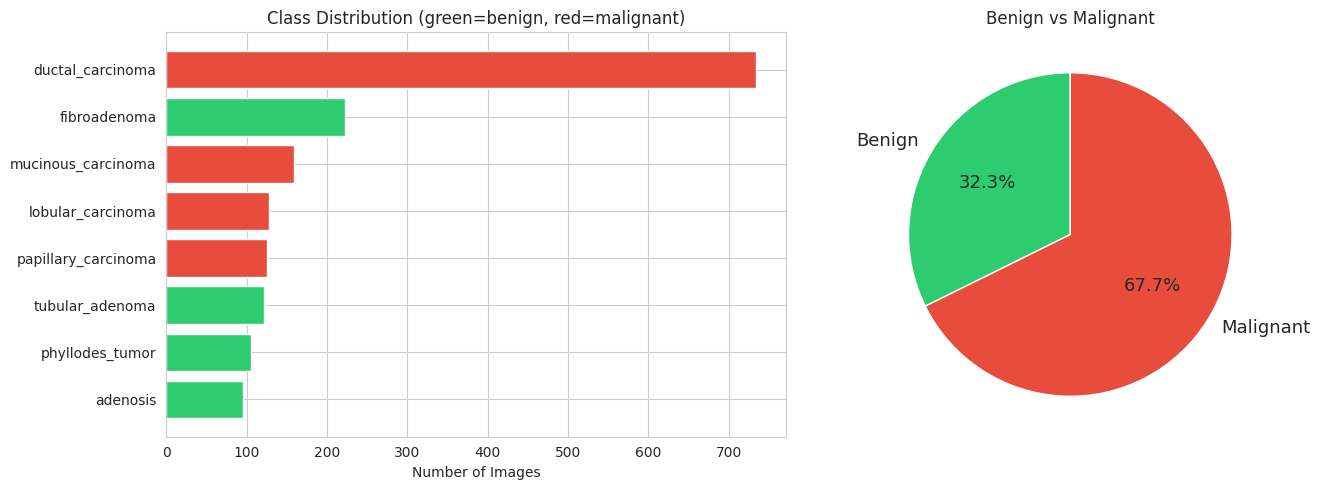


Benign: 547 (32.3%)
Malignant: 1146 (67.7%)

Imbalance ratio (max/min): 7.6x


In [6]:
# 3.1 Class distribution
class_counts = {}
for cls in CLASS_NAMES:
    cls_dir = os.path.join(ORGANIZED_DIR, cls)
    if os.path.isdir(cls_dir):
        count = len([f for f in os.listdir(cls_dir) if f.lower().endswith((".png", ".jpg", ".jpeg"))])
        class_counts[cls] = count

total = sum(class_counts.values())
print(f"Total images: {total}\n")

# Create a nice summary table
df_dist = pd.DataFrame({
    "Class": class_counts.keys(),
    "Count": class_counts.values(),
    "Percentage": [f"{100*v/total:.1f}%" for v in class_counts.values()],
    "Type": ["Benign" if c in BENIGN_CLASSES else "Malignant" for c in class_counts.keys()]
})
df_dist = df_dist.sort_values("Count", ascending=False).reset_index(drop=True)
print(df_dist.to_string(index=False))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart by class
colors = ["#2ecc71" if c in BENIGN_CLASSES else "#e74c3c" for c in df_dist["Class"]]
axes[0].barh(df_dist["Class"], df_dist["Count"], color=colors)
axes[0].set_xlabel("Number of Images")
axes[0].set_title("Class Distribution (green=benign, red=malignant)")
axes[0].invert_yaxis()

# Pie chart: benign vs malignant
benign_total = sum(v for k, v in class_counts.items() if k in BENIGN_CLASSES)
malignant_total = sum(v for k, v in class_counts.items() if k in MALIGNANT_CLASSES)
axes[1].pie(
    [benign_total, malignant_total],
    labels=["Benign", "Malignant"],
    colors=["#2ecc71", "#e74c3c"],
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 13}
)
axes[1].set_title("Benign vs Malignant")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "class_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"\nBenign: {benign_total} ({100*benign_total/total:.1f}%)")
print(f"Malignant: {malignant_total} ({100*malignant_total/total:.1f}%)")
print(f"\nImbalance ratio (max/min): {max(class_counts.values()) / max(min(class_counts.values()), 1):.1f}x")

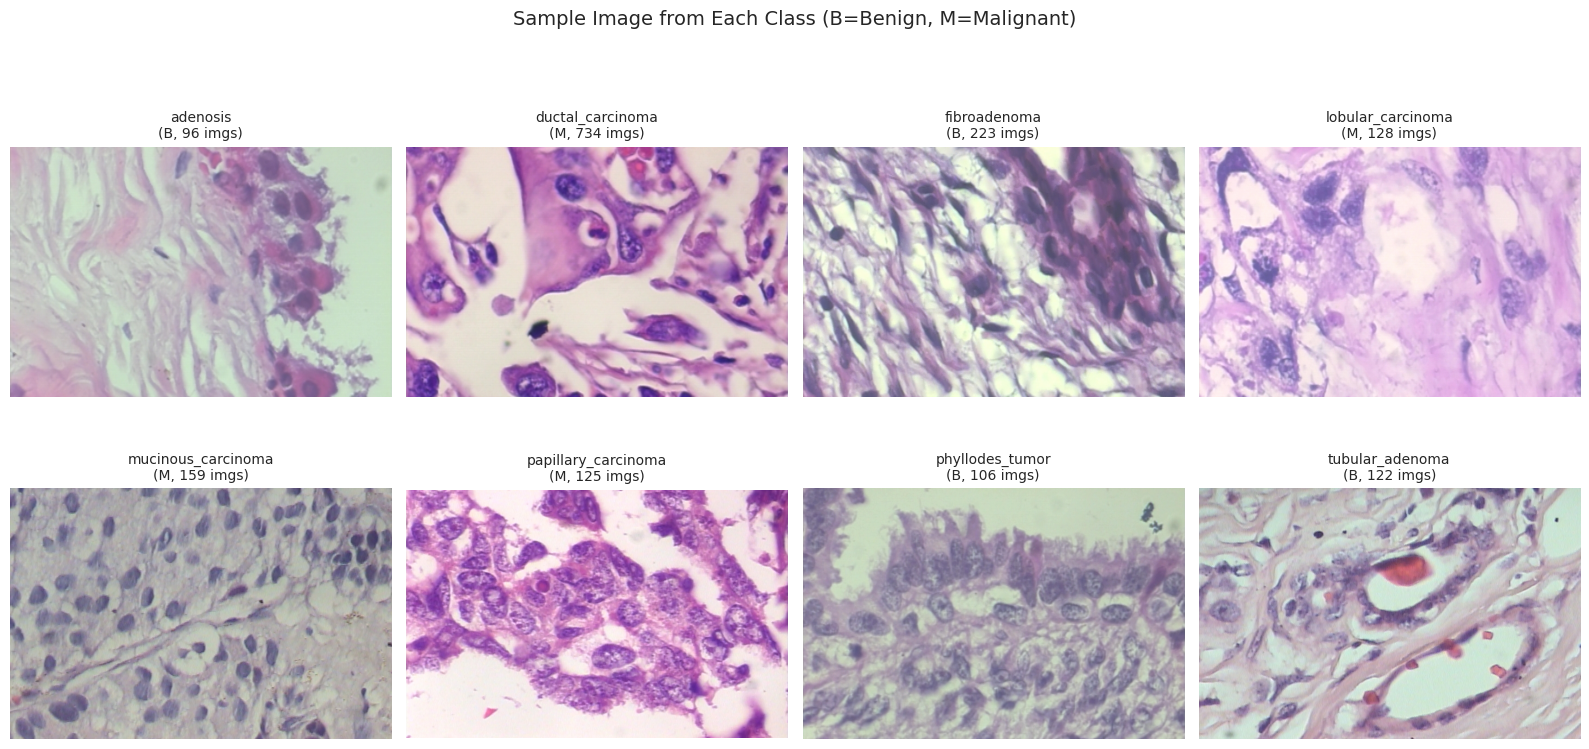

In [7]:
# 3.2 Sample images from each class
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for idx, cls in enumerate(CLASS_NAMES):
    ax = axes[idx // 4, idx % 4]
    cls_dir = os.path.join(ORGANIZED_DIR, cls)
    if os.path.isdir(cls_dir):
        images = sorted(os.listdir(cls_dir))
        if images:
            img = Image.open(os.path.join(cls_dir, images[0]))
            ax.imshow(img)
            label_type = "B" if cls in BENIGN_CLASSES else "M"
            ax.set_title(f"{cls}\n({label_type}, {class_counts.get(cls, 0)} imgs)", fontsize=10)
    ax.axis("off")

plt.suptitle("Sample Image from Each Class (B=Benign, M=Malignant)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "sample_images.png"), dpi=150, bbox_inches="tight")
plt.show()

Analyzing images:   0%|          | 0/200 [00:00<?, ?it/s]

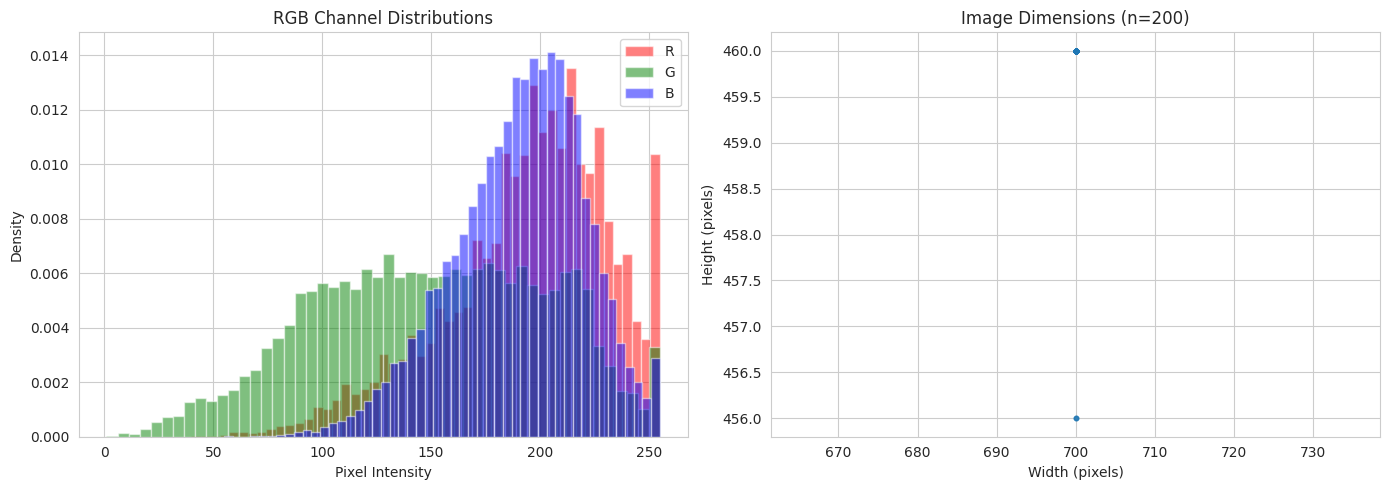

Image dimensions: 700x456 to 700x460
Most common: ((700, 460), 197)


In [8]:
# 3.3 Image statistics - pixel intensity distribution per channel
sample_pixels = {"R": [], "G": [], "B": []}
n_samples = min(200, total)

all_images = []
for cls in CLASS_NAMES:
    cls_dir = os.path.join(ORGANIZED_DIR, cls)
    if os.path.isdir(cls_dir):
        for f in os.listdir(cls_dir):
            if f.lower().endswith((".png", ".jpg", ".jpeg")):
                all_images.append(os.path.join(cls_dir, f))

random.shuffle(all_images)
widths, heights = [], []

for img_path in tqdm(all_images[:n_samples], desc="Analyzing images"):
    img = np.array(Image.open(img_path).convert("RGB"))
    h, w = img.shape[:2]
    widths.append(w)
    heights.append(h)
    flat = img.reshape(-1, 3)
    idx = np.random.choice(len(flat), size=min(100, len(flat)), replace=False)
    for ch, name in enumerate(["R", "G", "B"]):
        sample_pixels[name].extend(flat[idx, ch].tolist())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ch, color in [("R", "red"), ("G", "green"), ("B", "blue")]:
    axes[0].hist(sample_pixels[ch], bins=50, alpha=0.5, color=color, label=ch, density=True)
axes[0].set_xlabel("Pixel Intensity")
axes[0].set_ylabel("Density")
axes[0].set_title("RGB Channel Distributions")
axes[0].legend()

axes[1].scatter(widths, heights, alpha=0.5, s=10)
axes[1].set_xlabel("Width (pixels)")
axes[1].set_ylabel("Height (pixels)")
axes[1].set_title(f"Image Dimensions (n={n_samples})")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "image_statistics.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"Image dimensions: {min(widths)}x{min(heights)} to {max(widths)}x{max(heights)}")
print(f"Most common: {Counter(zip(widths, heights)).most_common(1)[0]}")

## 4. Stain Normalization (Ablation Study)

### What is H&E Staining?

Pathologists prepare tissue samples by staining them with **Hematoxylin & Eosin (H&E)**:
- **Hematoxylin** (blue/purple) stains **cell nuclei** (DNA)
- **Eosin** (pink) stains **cytoplasm and extracellular matrix** (proteins)

The problem: different labs use slightly different dye concentrations, temperatures, and timing. This means the **same tissue type can look very different** depending on where it was prepared. A model trained on one lab's slides may fail on another's.

### Our Ablation Study

We compare three approaches:
1. **None** (baseline) - Use raw images as-is
2. **Macenko** - Mathematically separates H&E stains using Optical Density space + SVD, then rescales to match a reference
3. **Reinhard** - Simpler approach: match the mean and standard deviation of LAB color channels to a reference image

By training the model three times (one per method) and comparing results, we can quantify whether stain normalization actually helps for our task.

Reference image: /home/abdullah/Documents/GitHub/Personal/densnet-thesis/thesis-v1-agent-abdullah/data/raw/organized/ductal_carcinoma/SOB_M_DC-14-17614-400-025.png
Shape: (460, 700, 3)


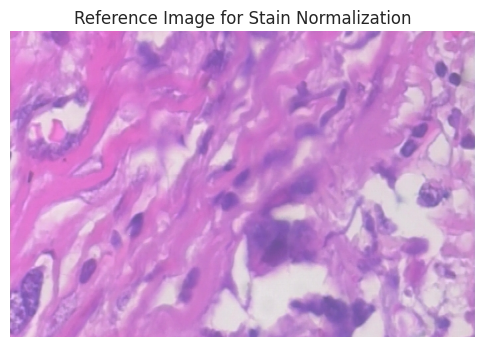

In [9]:
# 4.1 Select a reference image for normalization
ref_class = "ductal_carcinoma"
ref_dir = os.path.join(ORGANIZED_DIR, ref_class)
ref_images = sorted(os.listdir(ref_dir))
ref_image_path = os.path.join(ref_dir, ref_images[len(ref_images) // 2])
ref_image = np.array(Image.open(ref_image_path).convert("RGB"))

print(f"Reference image: {ref_image_path}")
print(f"Shape: {ref_image.shape}")
plt.figure(figsize=(6, 4))
plt.imshow(ref_image)
plt.title("Reference Image for Stain Normalization")
plt.axis("off")
plt.show()

/home/abdullah/Documents/GitHub/Personal/densnet-thesis/thesis-v1-agent-abdullah/src/stain_normalization.py:74: RuntimeWarning: overflow encountered in exp
  rgb = 255.0 * np.exp(-od)
/home/abdullah/Documents/GitHub/Personal/densnet-thesis/thesis-v1-agent-abdullah/src/stain_normalization.py:74: RuntimeWarning: overflow encountered in multiply
  rgb = 255.0 * np.exp(-od)


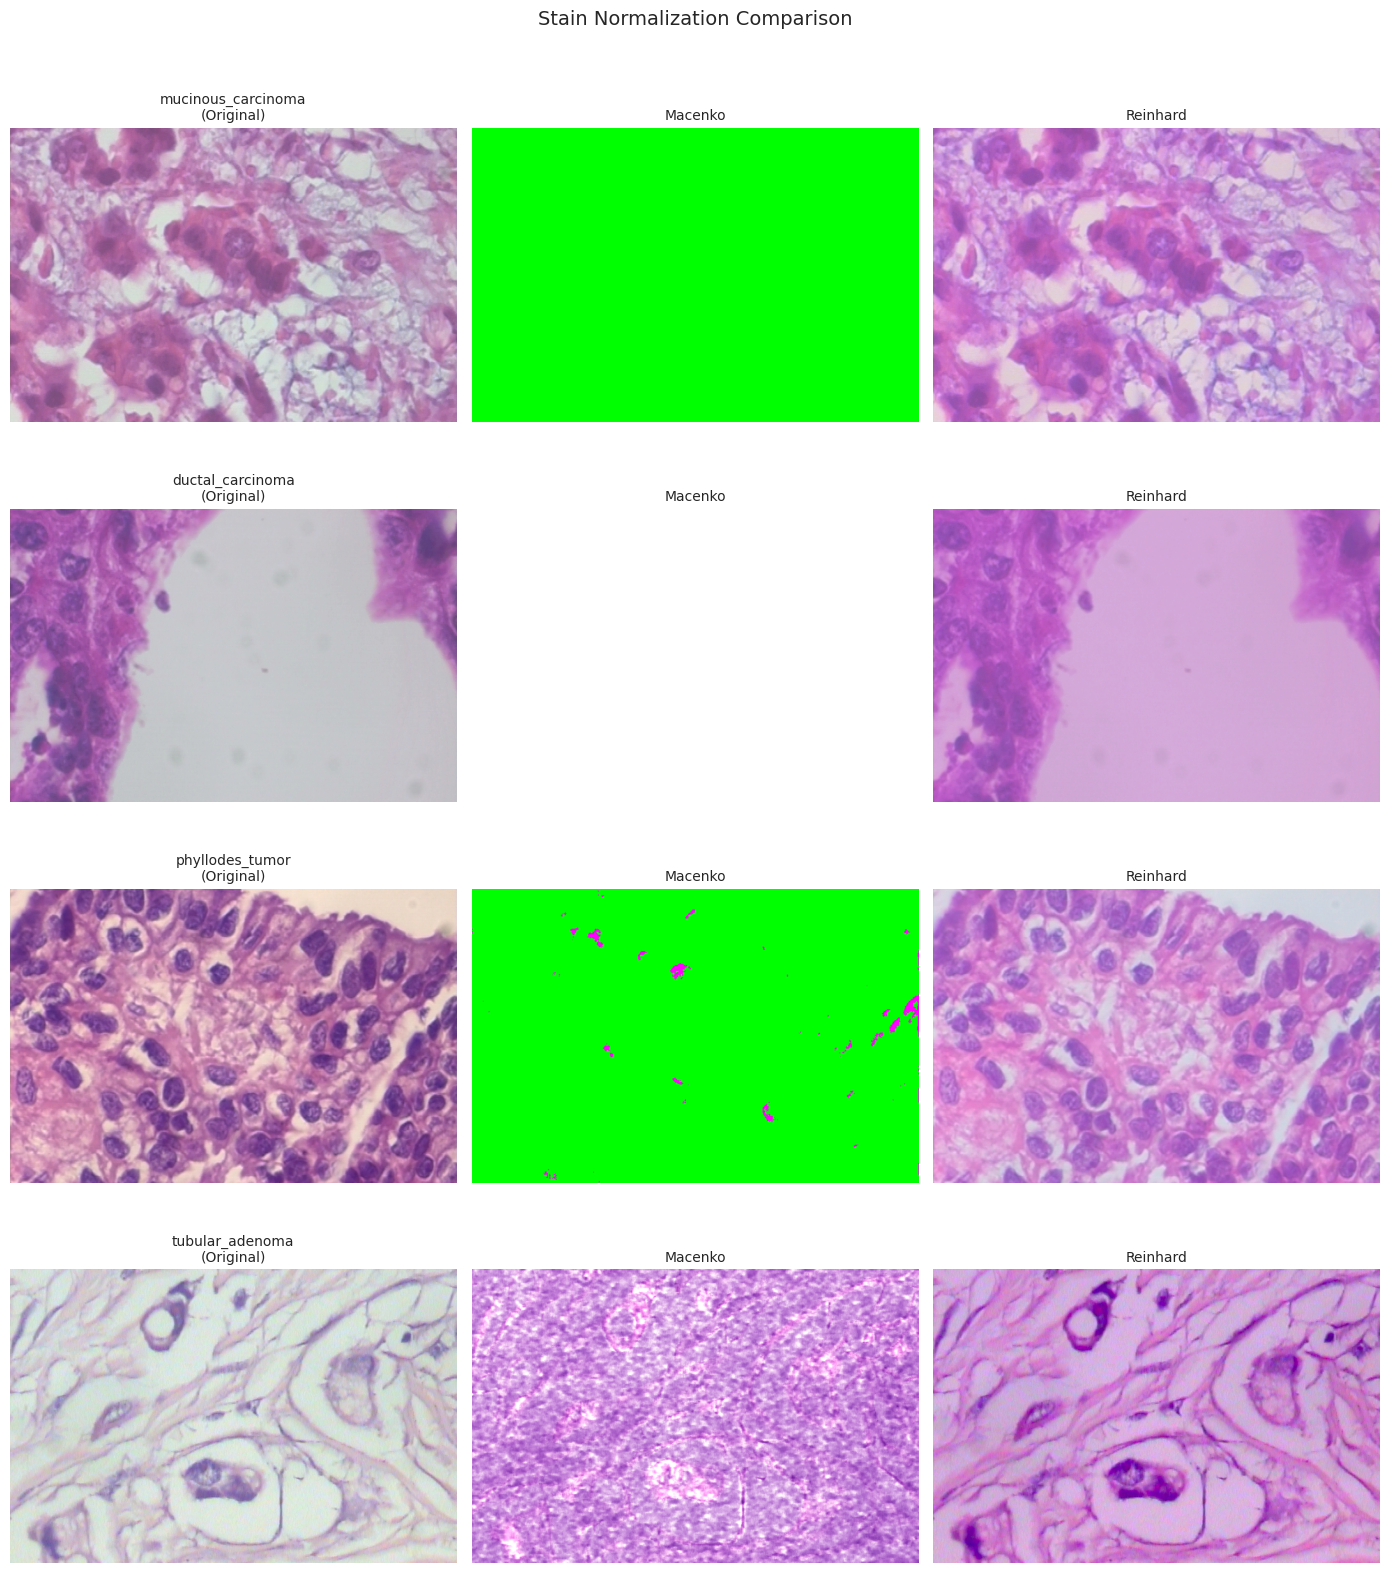

In [10]:
# 4.2 Demonstrate both normalization methods on sample images
demo_images = []
for cls in random.sample(CLASS_NAMES, 4):
    cls_dir = os.path.join(ORGANIZED_DIR, cls)
    imgs = os.listdir(cls_dir)
    img_path = os.path.join(cls_dir, random.choice(imgs))
    demo_images.append((cls, np.array(Image.open(img_path).convert("RGB"))))

# Fit normalizers to reference
macenko = MacenkoNormalizer()
macenko.fit(ref_image)

reinhard = ReinhardNormalizer()
reinhard.fit(ref_image)

# Visualize: Original | Macenko | Reinhard
fig, axes = plt.subplots(len(demo_images), 3, figsize=(14, 4 * len(demo_images)))

for row, (cls, img) in enumerate(demo_images):
    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f"{cls}\n(Original)", fontsize=10)
    axes[row, 0].axis("off")

    try:
        mac_img = macenko.normalize(img)
    except Exception as e:
        mac_img = img
        print(f"Macenko failed for {cls}: {e}")
    axes[row, 1].imshow(mac_img)
    axes[row, 1].set_title("Macenko", fontsize=10)
    axes[row, 1].axis("off")

    rein_img = reinhard.normalize(img)
    axes[row, 2].imshow(rein_img)
    axes[row, 2].set_title("Reinhard", fontsize=10)
    axes[row, 2].axis("off")

plt.suptitle("Stain Normalization Comparison", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "stain_normalization_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

## 5. Train / Validation / Test Split

We split the data **per class** (stratified) to ensure each split has the same class proportions:
- **Train (70%)** - Model learns from these images
- **Validation (15%)** - Used to tune hyperparameters and detect overfitting during training
- **Test (15%)** - Held out completely until final evaluation (touched only once!)

**Why stratified?** If we split randomly, rare classes (like lobular carcinoma) might have very few or zero images in the test set, making evaluation unreliable.

We create **3 versions** of the split: one for each stain normalization variant (none, macenko, reinhard).

In [11]:
# 5.1 Stratified split (same split indices for all stain variants)
from sklearn.model_selection import train_test_split

def stratified_split(organized_dir, seed=RANDOM_SEED):
    """Create stratified train/val/test split indices."""
    splits = {}
    for cls in CLASS_NAMES:
        cls_dir = os.path.join(organized_dir, cls)
        if not os.path.isdir(cls_dir):
            continue
        files = sorted([f for f in os.listdir(cls_dir) if f.lower().endswith((".png", ".jpg", ".jpeg"))])

        # First split: train vs (val+test)
        train_files, valtest_files = train_test_split(
            files, test_size=(VAL_RATIO + TEST_RATIO), random_state=seed
        )
        # Second split: val vs test
        val_files, test_files = train_test_split(
            valtest_files, test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO), random_state=seed
        )
        splits[cls] = {"train": train_files, "val": val_files, "test": test_files}

    return splits

split_indices = stratified_split(ORGANIZED_DIR)

# Print split statistics
print(f"Split ratios: train={TRAIN_RATIO}, val={VAL_RATIO}, test={TEST_RATIO}\n")
print(f"{'Class':<22} {'Train':>6} {'Val':>6} {'Test':>6} {'Total':>6}")
print("-" * 50)
totals = {"train": 0, "val": 0, "test": 0}
for cls in CLASS_NAMES:
    if cls in split_indices:
        s = split_indices[cls]
        print(f"{cls:<22} {len(s['train']):>6} {len(s['val']):>6} {len(s['test']):>6} {len(s['train'])+len(s['val'])+len(s['test']):>6}")
        for split in ["train", "val", "test"]:
            totals[split] += len(s[split])
print("-" * 50)
print(f"{'TOTAL':<22} {totals['train']:>6} {totals['val']:>6} {totals['test']:>6} {sum(totals.values()):>6}")

Split ratios: train=0.7, val=0.15, test=0.15

Class                   Train    Val   Test  Total
--------------------------------------------------
adenosis                   67     14     15     96
ductal_carcinoma          513    110    111    734
fibroadenoma              156     33     34    223
lobular_carcinoma          89     19     20    128
mucinous_carcinoma        111     24     24    159
papillary_carcinoma        87     19     19    125
phyllodes_tumor            74     16     16    106
tubular_adenoma            85     18     19    122
--------------------------------------------------
TOTAL                    1182    253    258   1693


In [12]:
# 5.2 Copy images into split directories for each stain normalization variant
# Structure: data/processed/{method}/{split}/{class}/image.png

def create_split_directories(organized_dir, split_indices, stain_methods=STAIN_METHODS):
    """Create train/val/test folders for each stain normalization variant."""
    normalizers = {}
    for method in stain_methods:
        normalizers[method] = get_normalizer(method)
        if normalizers[method] is not None:
            normalizers[method].fit(ref_image)

    for method in stain_methods:
        method_dir = os.path.join(PROCESSED_DATA_DIR, method)
        marker = os.path.join(method_dir, ".split_complete")
        if os.path.exists(marker):
            print(f"[{method}] Already processed. Skipping.")
            continue

        print(f"\n[{method}] Processing...")
        normalizer = normalizers[method]
        count = 0

        for cls in tqdm(CLASS_NAMES, desc=f"{method}"):
            for split in ["train", "val", "test"]:
                out_dir = os.path.join(method_dir, split, cls)
                os.makedirs(out_dir, exist_ok=True)

                for fname in split_indices.get(cls, {}).get(split, []):
                    src_path = os.path.join(organized_dir, cls, fname)
                    dst_path = os.path.join(out_dir, fname)

                    if os.path.exists(dst_path):
                        count += 1
                        continue

                    img = np.array(Image.open(src_path).convert("RGB"))

                    if normalizer is not None:
                        try:
                            img = normalizer.normalize(img)
                        except Exception:
                            pass

                    Image.fromarray(img).save(dst_path)
                    count += 1

        Path(marker).touch()
        print(f"[{method}] Done - {count} images")

create_split_directories(ORGANIZED_DIR, split_indices)


[none] Processing...


none:   0%|          | 0/8 [00:00<?, ?it/s]

[none] Done - 1693 images

[macenko] Processing...


macenko:   0%|          | 0/8 [00:00<?, ?it/s]

[macenko] Done - 1693 images

[reinhard] Processing...


reinhard:   0%|          | 0/8 [00:00<?, ?it/s]

[reinhard] Done - 1693 images


In [13]:
# 5.3 Verify the split directories
print("Processed data structure:\n")
for method in STAIN_METHODS:
    method_dir = os.path.join(PROCESSED_DATA_DIR, method)
    print(f"  {method}/")
    for split in ["train", "val", "test"]:
        split_dir = os.path.join(method_dir, split)
        if os.path.isdir(split_dir):
            n = sum(
                len([f for f in os.listdir(os.path.join(split_dir, c)) if f.lower().endswith((".png", ".jpg"))])
                for c in os.listdir(split_dir) if os.path.isdir(os.path.join(split_dir, c))
            )
            print(f"    {split}: {n} images")
    print()

Processed data structure:

  none/
    train: 1182 images
    val: 253 images
    test: 258 images

  macenko/
    train: 1182 images
    val: 253 images
    test: 258 images

  reinhard/
    train: 1182 images
    val: 253 images
    test: 258 images



## 6. Data Augmentation & Transforms

### Why Augmentation?

With ~7,900 images split 70/15/15, we have roughly **5,500 training images** across 8 classes. That's small by deep learning standards. Data augmentation artificially increases the effective training set size by applying random transformations:

| Augmentation | Why it makes sense for histopathology |
|---|---|
| **Random Horizontal/Vertical Flip** | Tissue orientation under the microscope is arbitrary |
| **Random Rotation (90 deg)** | Same reason - cells don't have "up" |
| **Random Resized Crop** | Simulates different zoom levels within the slide |
| **Color Jitter** | Complements stain normalization - handles residual color variation |
| **Random Erasing** | Forces the model to not rely on any single region (regularization) |

### Why ImageNet Normalization?

We use `mean=[0.485, 0.456, 0.406]` and `std=[0.229, 0.224, 0.225]` - these are ImageNet statistics, NOT BreakHis statistics. This is because our ConvNeXt and Swin backbones were **pretrained on ImageNet**. The pretrained weights expect inputs normalized this way. If we used different normalization, the pretrained features would be meaningless.

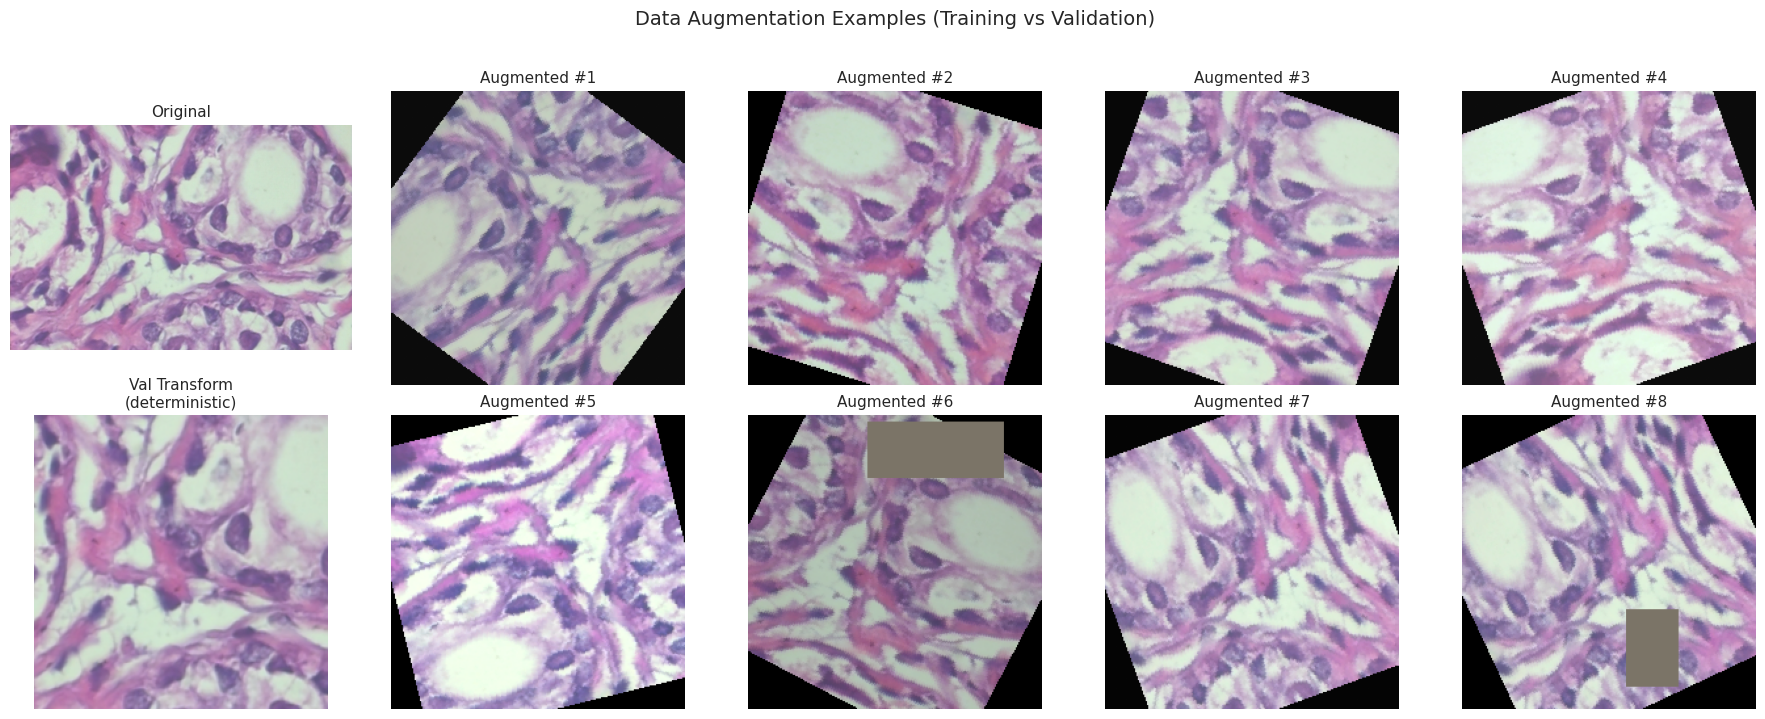

Training transforms: Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.5)
    RandomRotation(degrees=[-90.0, 90.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.85, 1.15), contrast=(0.85, 1.15), saturation=(0.9, 1.1), hue=(-0.05, 0.05))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    RandomErasing(p=0.1, scale=(0.02, 0.1), ratio=(0.3, 3.3), value=0, inplace=False)
)

Validation transforms: Compose(
    Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [14]:
# 6.1 Visualize augmentation effects on a single image
sample_cls = CLASS_NAMES[0]
sample_dir = os.path.join(PROCESSED_DATA_DIR, "none", "train", sample_cls)
sample_files = os.listdir(sample_dir)
sample_path = os.path.join(sample_dir, sample_files[0])
sample_img = Image.open(sample_path).convert("RGB")

train_transform = get_transforms("train")
val_transform = get_transforms("val")

fig, axes = plt.subplots(2, 5, figsize=(18, 7))

# Row 1: Original + 4 augmented versions
axes[0, 0].imshow(sample_img)
axes[0, 0].set_title("Original", fontsize=11)
axes[0, 0].axis("off")

for i in range(1, 5):
    augmented = train_transform(sample_img)
    denorm = augmented.clone()
    for ch in range(3):
        denorm[ch] = denorm[ch] * IMAGENET_STD[ch] + IMAGENET_MEAN[ch]
    denorm = denorm.clamp(0, 1).permute(1, 2, 0).numpy()
    axes[0, i].imshow(denorm)
    axes[0, i].set_title(f"Augmented #{i}", fontsize=11)
    axes[0, i].axis("off")

# Row 2: Validation transform + more augmented
val_img = val_transform(sample_img)
denorm_val = val_img.clone()
for ch in range(3):
    denorm_val[ch] = denorm_val[ch] * IMAGENET_STD[ch] + IMAGENET_MEAN[ch]
denorm_val = denorm_val.clamp(0, 1).permute(1, 2, 0).numpy()
axes[1, 0].imshow(denorm_val)
axes[1, 0].set_title("Val Transform\n(deterministic)", fontsize=11)
axes[1, 0].axis("off")

for i in range(1, 5):
    augmented = train_transform(sample_img)
    denorm = augmented.clone()
    for ch in range(3):
        denorm[ch] = denorm[ch] * IMAGENET_STD[ch] + IMAGENET_MEAN[ch]
    denorm = denorm.clamp(0, 1).permute(1, 2, 0).numpy()
    axes[1, i].imshow(denorm)
    axes[1, i].set_title(f"Augmented #{i+4}", fontsize=11)
    axes[1, i].axis("off")

plt.suptitle("Data Augmentation Examples (Training vs Validation)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "augmentation_examples.png"), dpi=150, bbox_inches="tight")
plt.show()

print("Training transforms:", train_transform)
print("\nValidation transforms:", val_transform)

## 7. DataLoader Verification

Final step: create PyTorch DataLoaders and verify a batch flows through correctly. This is our sanity check before moving to model training.

### Class-Balanced Sampling

BreakHis is **imbalanced** - ductal carcinoma has ~2.5x more images than some benign classes. Without handling this, the model would learn to always predict the majority class (high accuracy but useless).

We use **WeightedRandomSampler** during training: images from rare classes are sampled more frequently, so each batch sees roughly equal representation of all classes. We also compute **class weights** for the loss function as a second line of defense.

In [15]:
# 7.1 Create DataLoaders for the "none" (baseline) variant
method = "none"
train_dir = os.path.join(PROCESSED_DATA_DIR, method, "train")
val_dir = os.path.join(PROCESSED_DATA_DIR, method, "val")
test_dir = os.path.join(PROCESSED_DATA_DIR, method, "test")

train_loader, val_loader, test_loader, class_weights = create_dataloaders(
    train_dir, val_dir, test_dir, batch_size=BATCH_SIZE
)

print(f"Train: {len(train_loader.dataset)} images, {len(train_loader)} batches")
print(f"Val:   {len(val_loader.dataset)} images, {len(val_loader)} batches")
print(f"Test:  {len(test_loader.dataset)} images, {len(test_loader)} batches")
print(f"\nClass weights (for loss function):")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  {cls}: {class_weights[i]:.3f}")

Train: 1182 images, 36 batches
Val:   253 images, 8 batches
Test:  258 images, 9 batches

Class weights (for loss function):
  adenosis: 2.205
  ductal_carcinoma: 0.288
  fibroadenoma: 0.947
  lobular_carcinoma: 1.660
  mucinous_carcinoma: 1.331
  papillary_carcinoma: 1.698
  phyllodes_tumor: 1.997
  tubular_adenoma: 1.738


Batch shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Label distribution in batch: {np.int64(2): 3, np.int64(4): 2, np.int64(5): 4, np.int64(3): 5, np.int64(1): 4, np.int64(0): 5, np.int64(6): 5, np.int64(7): 4}
Pixel range: [-2.12, 2.64]


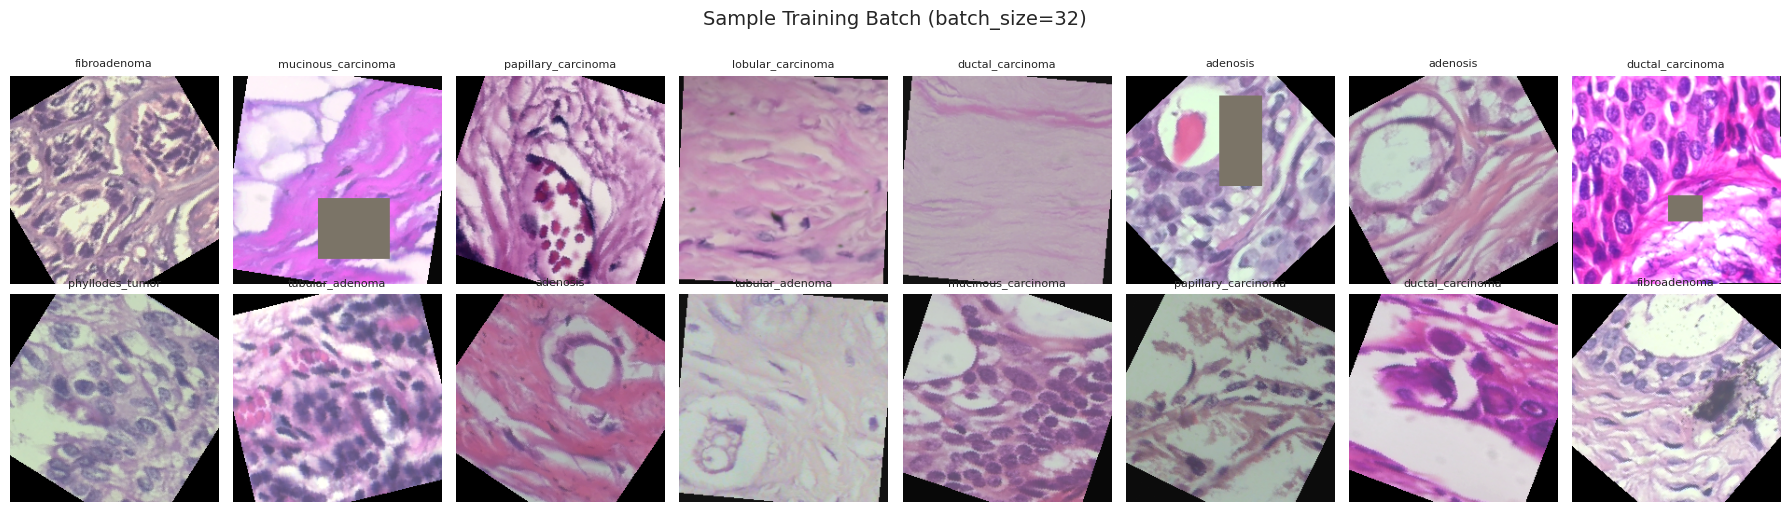

In [16]:
# 7.2 Verify a training batch
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}")  # Expected: [32, 3, 224, 224]
print(f"Labels shape: {labels.shape}")  # Expected: [32]
print(f"Label distribution in batch: {dict(Counter(labels.numpy()))}")
print(f"Pixel range: [{images.min():.2f}, {images.max():.2f}]")

# Display the batch
fig, axes = plt.subplots(2, 8, figsize=(18, 5))
for i in range(16):
    ax = axes[i // 8, i % 8]
    img = images[i].clone()
    for ch in range(3):
        img[ch] = img[ch] * IMAGENET_STD[ch] + IMAGENET_MEAN[ch]
    img = img.clamp(0, 1).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(CLASS_NAMES[labels[i]], fontsize=8)
    ax.axis("off")

plt.suptitle(f"Sample Training Batch (batch_size={BATCH_SIZE})", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Summary & Save Configuration

Data preparation is complete. Here's what we've built:

```
data/
├── raw/
│   └── organized/           # Original images in 8 class folders
└── processed/
    ├── none/                # No stain normalization
    │   ├── train/           # 70% of data
    │   ├── val/             # 15% of data
    │   └── test/            # 15% of data (untouched until final eval)
    ├── macenko/             # Macenko-normalized copies
    │   ├── train/
    │   ├── val/
    │   └── test/
    └── reinhard/            # Reinhard-normalized copies
        ├── train/
        ├── val/
        └── test/
```

**Next notebook**: `02_model_architecture.ipynb` - We'll define ConvNeXt and Swin Transformer models and prepare them for training.

In [17]:
# Save dataset metadata for use by subsequent notebooks
import json

metadata = {
    "dataset": "BreakHis 400X",
    "total_images": total,
    "num_classes": NUM_CLASSES,
    "class_names": CLASS_NAMES,
    "class_counts": class_counts,
    "split_ratios": {"train": TRAIN_RATIO, "val": VAL_RATIO, "test": TEST_RATIO},
    "split_counts": {
        cls: {split: len(files) for split, files in splits.items()}
        for cls, splits in split_indices.items()
    },
    "stain_methods": STAIN_METHODS,
    "image_size": IMAGE_SIZE,
    "normalization": {"mean": IMAGENET_MEAN, "std": IMAGENET_STD},
    "reference_image": ref_image_path,
    "random_seed": RANDOM_SEED,
}

metadata_path = os.path.join(DATA_DIR, "dataset_metadata.json")
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Metadata saved to: {metadata_path}")
print(f"\nData preparation complete! Ready for notebook 02.")

Metadata saved to: /home/abdullah/Documents/GitHub/Personal/densnet-thesis/thesis-v1-agent-abdullah/data/dataset_metadata.json

Data preparation complete! Ready for notebook 02.
